In [1]:
!pip install torch torchvision

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [2]:
import os
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image

# ==========================================
# DATASET PATH
# ==========================================

BASE_PATH = r"C:\Users\artec3d\Desktop\Datasets_raw\C-NMC_Leukemia"

TRAIN_PATH = os.path.join(
    BASE_PATH,
    "training_data",
    "fold_0"
)

# ==========================================
# CLASS LABELS
# ==========================================

CLASS_MAP = {
    "all": 0,
    "hem": 1
}

# ==========================================
# IMAGE TRANSFORMS
# ==========================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ==========================================
# CUSTOM DATASET
# ==========================================

class LeukemiaDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.samples = []

        for class_name in CLASS_MAP:

            class_folder = os.path.join(root_dir, class_name)

            for img_path in Path(class_folder).glob("*"):

                self.samples.append(
                    (
                        str(img_path),
                        CLASS_MAP[class_name]
                    )
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        sample = {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "path": img_path
        }

        return sample

# ==========================================
# CREATE DATASET
# ==========================================

train_dataset = LeukemiaDataset(
    TRAIN_PATH,
    transform=transform
)

# ==========================================
# CREATE DATALOADER
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# ==========================================
# CHECK LOADING
# ==========================================

batch = next(iter(train_loader))

print("Image Shape :", batch["image"].shape)
print("Labels Shape:", batch["label"].shape)

print("Example Path:")
print(batch["path"][0])

Image Shape : torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])
Example Path:
C:\Users\artec3d\Desktop\Datasets_raw\C-NMC_Leukemia\training_data\fold_0\hem\UID_H12_13_4_hem.bmp


In [3]:
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from PIL import Image

# ==========================================
# DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ==========================================
# DATASET PATH
# ==========================================
BASE_PATH = r"C:\Users\artec3d\Desktop\Datasets_raw\C-NMC_Leukemia"
TRAIN_PATH = os.path.join(BASE_PATH, "training_data", "fold_0")

# ==========================================
# CLASS LABELS
# ==========================================
CLASS_MAP = {"all": 0, "hem": 1}

# ==========================================
# IMAGE TRANSFORMS
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ==========================================
# CUSTOM DATASET
# ==========================================
class LeukemiaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        for class_name in CLASS_MAP:
            class_folder = os.path.join(root_dir, class_name)
            for img_path in Path(class_folder).glob("*"):
                self.samples.append((str(img_path), CLASS_MAP[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# CREATE DATASET + LOADER
# ==========================================
train_dataset = LeukemiaDataset(TRAIN_PATH, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

images, labels = next(iter(train_loader))
print("Image Shape :", images.shape)
print("Labels Shape:", labels.shape)
print("Total Loaded Images :", len(train_dataset))

# ==========================================
# LOAD PRETRAINED RESNET18 (updated API)
# ==========================================
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# ==========================================
# MODIFY FINAL LAYER
# ==========================================
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

# ==========================================
# LOSS FUNCTION + OPTIMIZER
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# TRAINING LOOP
# ==========================================
EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    accuracy   = 100 * correct / total
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Loss     : {epoch_loss:.4f}")
    print(f"Accuracy : {accuracy:.2f}%")

Using Device: cuda
Image Shape : torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])
Total Loaded Images : 3527

Epoch [1/5]
Loss     : 0.3887
Accuracy : 84.49%

Epoch [2/5]
Loss     : 0.2841
Accuracy : 88.94%

Epoch [3/5]
Loss     : 0.2321
Accuracy : 90.81%

Epoch [4/5]
Loss     : 0.2136
Accuracy : 91.69%

Epoch [5/5]
Loss     : 0.1710
Accuracy : 93.37%


In [4]:
from collections import Counter

labels = [sample[1] for sample in train_dataset.samples]

class_counts = Counter(labels)

print("Class-wise Image Count:\n")

for class_name, label in CLASS_MAP.items():

    print(f"{class_name} : {class_counts[label]}")
    

Class-wise Image Count:

all : 2397
hem : 1130


In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
CSV_PATH = r"C:\Users\artec3d\Desktop\Datasets_raw\enhanced_fever_medicine_recommendation.csv"

BATCH_SIZE = 32
EPOCHS = 30             # upper bound — early stopping will kick in before this
PATIENCE = 5            # stop if val loss doesn't improve for 5 epochs
LEARNING_RATE = 0.001

# Define our feature types based on the CSV
NUMERICAL_COLS = ['Temperature', 'Age', 'BMI', 'Humidity', 'AQI', 'Heart_Rate']
CATEGORICAL_COLS = [
    'Fever_Severity', 'Gender', 'Headache', 'Body_Ache', 'Fatigue',
    'Chronic_Conditions', 'Allergies', 'Smoking_History', 'Alcohol_Consumption',
    'Physical_Activity', 'Diet_Type', 'Blood_Pressure', 'Previous_Medication'
]
TARGET_COL = 'Recommended_Medication'

# ==========================================
# 2. Data Loading & Preprocessing
# ==========================================
print("Loading and preprocessing data...")
df = pd.read_csv(CSV_PATH)

# Encode Target
target_encoder = LabelEncoder()
df[TARGET_COL] = target_encoder.fit_transform(df[TARGET_COL])
num_classes = len(target_encoder.classes_)

# Scale Numerical Features
scaler = StandardScaler()
df[NUMERICAL_COLS] = scaler.fit_transform(df[NUMERICAL_COLS])

# Encode Categorical Features to Integers (for Embedding Layers)
cat_encoders = {}
cat_dims = []  # To store the number of unique values for each category

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    cat_encoders[col] = le
    cat_dims.append(len(le.classes_))

# ==========================================
# 3. PyTorch Dataset Definition
# ==========================================
class FeverDataset(Dataset):
    def __init__(self, dataframe):
        self.num_data = dataframe[NUMERICAL_COLS].values.astype(np.float32)
        self.cat_data = dataframe[CATEGORICAL_COLS].values.astype(np.int64)
        self.targets = dataframe[TARGET_COL].values.astype(np.int64)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.num_data[idx], self.cat_data[idx], self.targets[idx]

# Split data into train / val / test
# (previously had NO validation split — this was the root cause of overtraining)
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df     = train_test_split(train_val_df, test_size=0.15, random_state=42)  # ~12% of total

train_dataset = FeverDataset(train_df)
val_dataset   = FeverDataset(val_df)
test_dataset  = FeverDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. Multimodal-Ready Neural Network Model
# ==========================================
class TabularEmbeddingModel(nn.Module):
    def __init__(self, cat_dims, num_numerical_cols, num_classes):
        super(TabularEmbeddingModel, self).__init__()

        # Create an Embedding Layer for each categorical column
        # Rule of thumb for embedding size: min(50, num_categories // 2 + 1)
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=min(50, (dim + 1) // 2))
            for dim in cat_dims
        ])

        # Calculate total dimension after embeddings are concatenated
        total_emb_dim = sum(min(50, (dim + 1) // 2) for dim in cat_dims)

        # Total input dimension = embedded categories + numerical features
        input_dim = total_emb_dim + num_numerical_cols

        # Two hidden layers instead of one — more capacity, but regularized below
        self.fc1     = nn.Linear(input_dim, 128)
        self.fc2     = nn.Linear(128, 64)       # second hidden layer
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.4)          # increased from 0.2 → 0.4

        # THIS is the layer that outputs our "Tabular Embedding" (e.g., 16 numbers)
        # In the future, we will extract the output of this layer and combine it with Images/Audio
        self.tabular_embedding_layer = nn.Linear(64, 16)

        # Final Decision Layer (Only used when evaluating the tabular data alone)
        self.output_layer = nn.Linear(16, num_classes)

    def forward(self, num_x, cat_x):
        # 1. Pass categorical data through embedding layers
        emb_outputs = []
        for i, emb_layer in enumerate(self.embeddings):
            emb_outputs.append(emb_layer(cat_x[:, i]))

        # 2. Concatenate all embeddings together
        cat_embedded = torch.cat(emb_outputs, dim=1)

        # 3. Concatenate numerical data with the embedded categorical data
        x = torch.cat([num_x, cat_embedded], dim=1)

        # 4. Pass through hidden layers with dropout after each
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        # 5. Extract Tabular Embedding! (The 16 numbers)
        tabular_embedding = self.tabular_embedding_layer(x)
        tabular_embedding = self.relu(tabular_embedding)

        # 6. Final prediction
        out = self.output_layer(tabular_embedding)
        return out

model     = TabularEmbeddingModel(cat_dims, len(NUMERICAL_COLS), num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)  # L2 regularization added

# ==========================================
# 5. Training Loop with Validation & Early Stopping
# ==========================================
print("\nStarting Training...")
best_val_loss    = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for num_x, cat_x, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(num_x, cat_x)
        loss    = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    epoch_acc  = 100 * correct / total

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for num_x, cat_x, labels in val_loader:
            outputs   = model(num_x, cat_x)
            val_loss += criterion(outputs, labels).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Train Acc: {epoch_acc:.2f}% - Val Loss: {val_loss:.4f}")

    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss      = val_loss
        epochs_no_improve  = 0
        torch.save(model.state_dict(), 'tabular_model_weights.pth')  # save best weights only
    else:
        epochs_no_improve += 1
        if epochs_no_improve == PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (val loss didn't improve for {PATIENCE} epochs)")
            break

print("\nModel trained successfully!")
print("Best model weights saved to 'tabular_model_weights.pth'")
print("\nThis model is now fully prepared for multimodal integration. You can strip the 'output_layer' later to extract the 16-dimensional tabular embeddings!")


# 1. Instantiate the model architecture
model = TabularEmbeddingModel(cat_dims, len(NUMERICAL_COLS), num_classes)

# 2. Load the pre-trained weights
model.load_state_dict(torch.load('tabular_model_weights.pth'))

# 3. Put the model in "Evaluation Mode" (Crucial step!)
model.eval()

print("Pre-trained weights loaded successfully! No training required.")

# Grab one batch of patients from the test data
num_x, cat_x, labels = next(iter(test_loader))

# Let's look at the very first patient in this batch
patient_num = num_x[0].unsqueeze(0)
patient_cat = cat_x[0].unsqueeze(0)

# Pass the patient through the hidden layers (but NOT the final output layer)
with torch.no_grad():
    # 1. Get categorical embeddings
    emb_outputs  = [emb_layer(patient_cat[:, i]) for i, emb_layer in enumerate(model.embeddings)]
    cat_embedded = torch.cat(emb_outputs, dim=1)

    # 2. Mix with numerical data and pass through both hidden layers
    x = torch.cat([patient_num, cat_embedded], dim=1)
    x = model.fc1(x)
    x = model.relu(x)
    x = model.fc2(x)
    x = model.relu(x)

    # 3. Extract the final 16-number tabular embedding!
    tabular_embedding = model.tabular_embedding_layer(x)
    tabular_embedding = model.relu(tabular_embedding)

print("Here is the 16-number embedding for this patient:")
print(tabular_embedding)

Loading and preprocessing data...

Starting Training...
Epoch 1/30 - Train Loss: 0.5525 - Train Acc: 79.26% - Val Loss: 0.4444
Epoch 2/30 - Train Loss: 0.4632 - Train Acc: 79.26% - Val Loss: 0.3655
Epoch 3/30 - Train Loss: 0.3657 - Train Acc: 79.26% - Val Loss: 0.2691
Epoch 4/30 - Train Loss: 0.2707 - Train Acc: 80.59% - Val Loss: 0.1825
Epoch 5/30 - Train Loss: 0.1856 - Train Acc: 90.74% - Val Loss: 0.1164
Epoch 6/30 - Train Loss: 0.1105 - Train Acc: 97.94% - Val Loss: 0.0437
Epoch 7/30 - Train Loss: 0.0454 - Train Acc: 99.26% - Val Loss: 0.0068
Epoch 8/30 - Train Loss: 0.0101 - Train Acc: 100.00% - Val Loss: 0.0014
Epoch 9/30 - Train Loss: 0.0089 - Train Acc: 99.56% - Val Loss: 0.0010
Epoch 10/30 - Train Loss: 0.0044 - Train Acc: 100.00% - Val Loss: 0.0006
Epoch 11/30 - Train Loss: 0.0048 - Train Acc: 100.00% - Val Loss: 0.0003
Epoch 12/30 - Train Loss: 0.0019 - Train Acc: 100.00% - Val Loss: 0.0002
Epoch 13/30 - Train Loss: 0.0036 - Train Acc: 99.85% - Val Loss: 0.0002
Epoch 14/30 -

In [6]:
import os

BASE_PATH = r"C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB"

for root, dirs, files in os.walk(BASE_PATH):

    print(root)

    print("Files:", len(files))

    print("-" * 40)

C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB
Files: 7
----------------------------------------
C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB\.git
Files: 5
----------------------------------------
C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB\.git\hooks
Files: 14
----------------------------------------
C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB\.git\info
Files: 1
----------------------------------------
C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB\.git\logs
Files: 1
----------------------------------------
C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB\.git\logs\refs
Files: 0
----------------------------------------
C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB\.git\logs\refs\heads
Files: 1
----------------------------------------
C:\Users\artec3d\Desktop\diabetes-git\Voice-and-diabetes-VOCADIAB\.git\logs\refs\remotes
Files: 0
-----------------

In [7]:
import os

BASE_PATH = r"D:\AIPROJECTS\healthcare-ai"

for root, dirs, files in os.walk(BASE_PATH):

    audio_files = [
        f for f in files
        if f.endswith(".wav")
    ]

    if audio_files:

        print("\nFOLDER:", root)

        print("Number of WAV files:", len(audio_files))

        print("Sample Files:")

        for f in audio_files[:5]:

            print(f)

        print("-" * 50)


FOLDER: D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\2zDWjtjSxeUuy2or5XThZNSzvwO2
Number of WAV files: 9
Sample Files:
breathing-deep.wav
breathing-shallow.wav
cough-heavy.wav
cough-shallow.wav
counting-fast.wav
--------------------------------------------------

FOLDER: D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\5Gn8GDorBDaV9s4JhzMpppc3I3j1
Number of WAV files: 9
Sample Files:
breathing-deep.wav
breathing-shallow.wav
cough-heavy.wav
cough-shallow.wav
counting-fast.wav
--------------------------------------------------

FOLDER: D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\7PIIt8R3JWVfSFURfFyRR5ufM243
Number of WAV files: 9
Sample Files:
breathing-deep.wav
breathing-shallow.wav
cough-heavy.wav
cough-shallow.wav
counting-fast.wav
--------------------------------------------------

FOLDER: D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\2020080

In [8]:
import os
from pathlib import Path

# ==========================================
# DATASET PATH
# ==========================================

BASE_PATH = r"D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data"

# ==========================================
# FIND ALL WAV FILES
# ==========================================

wav_files = []

for path in Path(BASE_PATH).rglob("*.wav"):

    wav_files.append(str(path))

# ==========================================
# RESULTS
# ==========================================

print("Total WAV Files Found:", len(wav_files))

print("\nSample WAV Files:\n")

for file in wav_files[:10]:

    print(file)

Total WAV Files Found: 12564

Sample WAV Files:

D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\2zDWjtjSxeUuy2or5XThZNSzvwO2\breathing-deep.wav
D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\2zDWjtjSxeUuy2or5XThZNSzvwO2\breathing-shallow.wav
D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\2zDWjtjSxeUuy2or5XThZNSzvwO2\cough-heavy.wav
D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\2zDWjtjSxeUuy2or5XThZNSzvwO2\cough-shallow.wav
D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\2zDWjtjSxeUuy2or5XThZNSzvwO2\counting-fast.wav
D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\2zDWjtjSxeUuy2or5XThZNSzvwO2\counting-normal.wav
D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data\test\20200803\2zDWjtjSxeUuy2or5XThZNSzvwO2\vowel-a.wav
D:\AIPROJECTS\healthcare-ai\CoronaH

In [9]:
!pip install librosa

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


C:\Users\artec3d\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


Signal Shape: (415834,)
Sample Rate : 22050


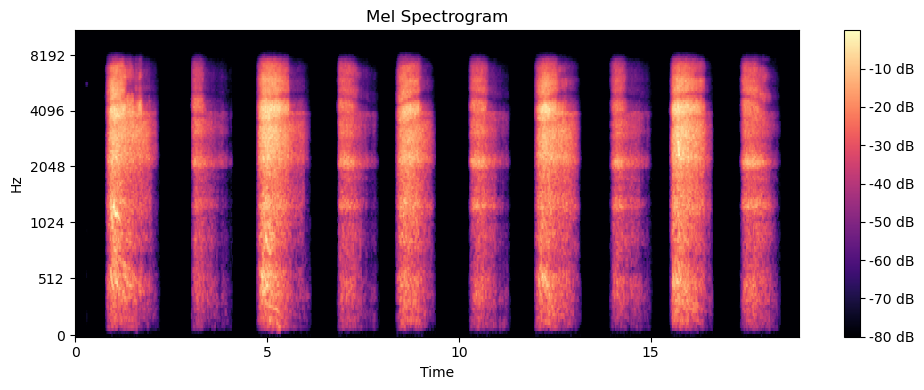

In [10]:

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# LOAD ONE AUDIO FILE
# ==========================================

audio_path = wav_files[0]

signal, sr = librosa.load(audio_path, sr=22050)

print("Signal Shape:", signal.shape)
print("Sample Rate :", sr)

# ==========================================
# CREATE MEL SPECTROGRAM
# ==========================================

mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

# ==========================================
# DISPLAY
# ==========================================

plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')

plt.title("Mel Spectrogram")

plt.tight_layout()

plt.show()

In [11]:
import os
from pathlib import Path

import librosa
import numpy as np

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [13]:
BASE_PATH = r"D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\data"

In [14]:
import pandas as pd

# ==========================================
# LOAD METADATA
# ==========================================
META_CSV = r"D:\AIPROJECTS\healthcare-ai\CoronaHack-Respiratory-Sound-Dataset\Corona-Hack-Respiratory-Sound-Metadata.csv"

meta_df = pd.read_csv(META_CSV, encoding='latin1')

# COVID_STATUS values in your CSV:
# 'healthy'                    → 0
# 'no_resp_illness_exposed'    → 0
# 'recovered_full'             → 0
# 'resp_illness_not_identified'→ 0
# 'positive_mild'              → 1
# 'positive_moderate'          → 1
# 'positive_asymp'             → 1

COVID_POSITIVE = {'positive_mild', 'positive_moderate', 'positive_asymp'}

label_map = {}
for _, row in meta_df.iterrows():
    uid    = str(row['USER_ID']).strip()
    status = str(row['COVID_STATUS']).strip()
    label_map[uid] = 1 if status in COVID_POSITIVE else 0

print("Total patients:", len(label_map))
print("COVID positive:", sum(v == 1 for v in label_map.values()))
print("COVID negative:", sum(v == 0 for v in label_map.values()))


# ==========================================
# FIXED AudioDataset WITH REAL LABELS
# ==========================================
class AudioDataset(Dataset):

    def __init__(self, root_dir, label_map):
        self.samples = []
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])

        for path in Path(root_dir).rglob("*.wav"):
            patient_id = path.parent.name   # folder name = USER_ID
            if patient_id in label_map:
                self.samples.append((str(path), label_map[patient_id]))

        print(f"Labeled audio files : {len(self.samples)}")
        pos = sum(1 for _, l in self.samples if l == 1)
        neg = sum(1 for _, l in self.samples if l == 0)
        print(f"  COVID positive     : {pos}")
        print(f"  COVID negative     : {neg}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        audio_path, label = self.samples[idx]

        try:
            signal, sr = librosa.load(audio_path, sr=22050)
            if len(signal) == 0:
                signal = np.zeros(22050)
        except Exception:
            signal = np.zeros(22050)
            sr = 22050

        mel_spec    = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        mn, mx = mel_spec_db.min(), mel_spec_db.max()
        if mx - mn > 0:
            mel_spec_db = (mel_spec_db - mn) / (mx - mn)
        else:
            mel_spec_db = np.zeros_like(mel_spec_db)

        mel_image = Image.fromarray(np.uint8(mel_spec_db * 255)).convert("RGB")
        mel_image = self.transform(mel_image)

        return mel_image, torch.tensor(label, dtype=torch.long)


# ==========================================
# RECREATE LOADER
# ==========================================
audio_dataset = AudioDataset(BASE_PATH, label_map)
audio_loader  = DataLoader(audio_dataset, batch_size=32, shuffle=True)

Total patients: 1397
COVID positive: 56
COVID negative: 1341
Labeled audio files : 12564
  COVID positive     : 504
  COVID negative     : 12060


In [15]:
audio_dataset = AudioDataset(BASE_PATH, label_map)

audio_loader = DataLoader(
    audio_dataset,
    batch_size=32,
    shuffle=True
)

print("Total Audio Files:", len(audio_dataset))

Labeled audio files : 12564
  COVID positive     : 504
  COVID negative     : 12060
Total Audio Files: 12564


In [16]:
images, labels = next(iter(audio_loader))

print("Batch Shape:", images.shape)

Batch Shape: torch.Size([32, 3, 224, 224])


In [17]:
from torchvision.models import ResNet18_Weights
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

In [18]:
num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Linear(num_features, 128),

    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(128, 2)

)

model = model.to(device)

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [20]:
print("hiii")

# ==========================================
# NOTE: AudioDataset uses dummy label=0 for all files.
# This is fine for embedding extraction, but the model
# converges to near-zero loss immediately because all
# labels are identical. Keeping EPOCHS=1 for embedding
# extraction; replace dummy labels with real ones when
# you have ground truth.
# ==========================================
EPOCHS = 1

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in audio_loader:
        images = images.to(device)
        labels = labels.to(device)

        # ======================
        # FORWARD
        # ======================
        outputs = model(images)
        loss    = criterion(outputs, labels)

        # ======================
        # BACKPROP
        # ======================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"\nEpoch {epoch+1}")
    print("Loss:", running_loss / len(audio_loader))

hiii


C:\Users\artec3d\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1882
  warnings.warn(



Epoch 1
Loss: 0.18347170443864155


In [21]:
model.eval()

sample_images, _ = next(iter(audio_loader))

sample_images = sample_images.to(device)

with torch.no_grad():

    features = model.avgpool(
        model.layer4(
            model.layer3(
                model.layer2(
                    model.layer1(
                        model.maxpool(
                            model.relu(
                                model.bn1(
                                    model.conv1(sample_images)
                                )
                            )
                        )
                    )
                )
            )
        )
    )

    features = torch.flatten(features, 1)

print("Audio Embedding Shape:")

print(features.shape)

Audio Embedding Shape:
torch.Size([32, 512])


In [22]:
torch.save(
    model.state_dict(),
    "blood_resnet18.pth"
)

In [23]:
torch.save(
    model.state_dict(),
    "audio_resnet18.pth"
)

In [24]:
# standardize & extract again

In [25]:
# ==========================================
# STANDARDIZED BLOOD EMBEDDING PIPELINE
# ==========================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import ResNet18_Weights

# ==========================================
# DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ==========================================
# RECREATE BLOOD DATASET + LOADER
# ==========================================
blood_dataset = LeukemiaDataset(TRAIN_PATH, transform=transform)
blood_loader  = DataLoader(blood_dataset, batch_size=32, shuffle=True)
print("Blood Loader Ready")

# ==========================================
# LOAD RESNET18 (updated API)
# ==========================================
blood_model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# ==========================================
# GET FEATURE SIZE
# ==========================================
num_features = blood_model.fc.in_features

# ==========================================
# STANDARDIZED EMBEDDING MODEL
# ==========================================
blood_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)
blood_model = blood_model.to(device)
blood_model.eval()
print("Blood Model Ready")

# ==========================================
# GET SAMPLE BATCH
# ==========================================
images, labels = next(iter(blood_loader))
images = images.to(device)

# ==========================================
# EXTRACT BLOOD EMBEDDINGS
# ==========================================
with torch.no_grad():
    x = blood_model.conv1(images)
    x = blood_model.bn1(x)
    x = blood_model.relu(x)
    x = blood_model.maxpool(x)
    x = blood_model.layer1(x)
    x = blood_model.layer2(x)
    x = blood_model.layer3(x)
    x = blood_model.layer4(x)
    x = blood_model.avgpool(x)
    x = torch.flatten(x, 1)

    # 512 -> 256
    x = blood_model.fc[0](x)
    x = blood_model.fc[1](x)
    x = blood_model.fc[2](x)

    # 256 -> 128
    blood_embedding = blood_model.fc[3](x)
    blood_embedding = blood_model.fc[4](blood_embedding)

print("\nBlood Embedding Shape:")
print(blood_embedding.shape)
print("\nSample Blood Embedding:")
print(blood_embedding[0])

Using Device: cuda
Blood Loader Ready
Blood Model Ready

Blood Embedding Shape:
torch.Size([32, 128])

Sample Blood Embedding:
tensor([0.0000, 0.1376, 0.0000, 0.2571, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.1801, 0.0000, 0.0000, 0.3231, 0.1240, 0.0000, 0.0021, 0.0840,
        0.2510, 0.3262, 0.0000, 0.0000, 0.2585, 0.0426, 0.0000, 0.0653, 0.0000,
        0.2318, 0.0724, 0.0000, 0.0000, 0.4116, 0.0470, 0.0000, 0.0000, 0.0830,
        0.1987, 0.0000, 0.0000, 0.0000, 0.0000, 0.1799, 0.2260, 0.4574, 0.0000,
        0.1083, 0.0000, 0.0959, 0.1139, 0.0000, 0.0000, 0.1173, 0.0000, 0.5446,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1116, 0.2707, 0.0000, 0.0000,
        0.0000, 0.5109, 0.0000, 0.0000, 0.2583, 0.1563, 0.0000, 0.0000, 0.0000,
        0.0000, 0.6222, 0.2833, 0.2064, 0.0000, 0.0000, 0.1681, 0.2915, 0.2983,
        0.3184, 0.7001, 0.2442, 0.0000, 0.4458, 0.0000, 0.1047, 0.0000, 0.0000,
        0.3245, 0.0130, 0.0000, 0.3158, 0.0000, 0.1304, 0.0000, 0.0000, 0

In [26]:
# ==========================================
# AUDIO RESNET18 STANDARDIZED
# ==========================================
from torchvision.models import ResNet18_Weights

audio_model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
num_features = audio_model.fc.in_features
audio_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU()
)
audio_model = audio_model.to(device)
print("Audio Model Ready")

audio_model.eval()
sample_images, _ = next(iter(audio_loader))
sample_images     = sample_images.to(device)

with torch.no_grad():
    audio_embedding = audio_model(sample_images)

print("Audio Embedding Shape:")
print(audio_embedding.shape)

Audio Model Ready
Audio Embedding Shape:
torch.Size([32, 128])


In [27]:
# ==========================================
# STANDARDIZED TABULAR MODEL
# ==========================================

class TabularEmbeddingModel(nn.Module):

    def __init__(
        self,
        cat_dims,
        num_numerical_cols,
        num_classes
    ):

        super(TabularEmbeddingModel, self).__init__()

        # ==================================
        # CATEGORICAL EMBEDDINGS
        # ==================================

        self.embeddings = nn.ModuleList([

            nn.Embedding(
                num_embeddings=dim,
                embedding_dim=min(
                    50,
                    (dim + 1) // 2
                )
            )

            for dim in cat_dims

        ])

        # ==================================
        # TOTAL EMBEDDING DIM
        # ==================================

        total_emb_dim = sum(

            min(50, (dim + 1) // 2)

            for dim in cat_dims
        )

        # ==================================
        # INPUT DIMENSION
        # ==================================

        input_dim = (
            total_emb_dim +
            num_numerical_cols
        )

        # ==================================
        # FEATURE NETWORK
        # ==================================

        self.fc1 = nn.Linear(
            input_dim,
            64
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.2)

        # ==================================
        # STANDARDIZED 128-D EMBEDDING
        # ==================================

        self.tabular_embedding_layer = nn.Linear(
            64,
            128
        )

        # ==================================
        # FINAL CLASSIFIER
        # ==================================

        self.output_layer = nn.Linear(
            128,
            num_classes
        )

    def forward(
        self,
        num_x,
        cat_x
    ):

        # ==================================
        # EMBEDDINGS
        # ==================================

        emb_outputs = []

        for i, emb_layer in enumerate(self.embeddings):

            emb_outputs.append(
                emb_layer(cat_x[:, i])
            )

        cat_embedded = torch.cat(
            emb_outputs,
            dim=1
        )

        # ==================================
        # CONCATENATE FEATURES
        # ==================================

        x = torch.cat(
            [num_x, cat_embedded],
            dim=1
        )

        # ==================================
        # HIDDEN LAYERS
        # ==================================

        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout(x)

        # ==================================
        # 128-D EMBEDDING
        # ==================================

        tabular_embedding = self.tabular_embedding_layer(x)

        tabular_embedding = self.relu(
            tabular_embedding
        )

        # ==================================
        # FINAL OUTPUT
        # ==================================

        out = self.output_layer(
            tabular_embedding
        )

        return out

In [28]:
# ==========================================
# STANDARDIZED TABULAR TRAINING CELL
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# ==========================================
# DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ==========================================
# TRAIN / VAL SPLIT FOR TABULAR DATA
# ==========================================
train_val_df2, test_df2 = train_test_split(df, test_size=0.2, random_state=42)
train_df2, val_df2      = train_test_split(train_val_df2, test_size=0.15, random_state=42)

tabular_train_dataset = FeverDataset(train_df2)
tabular_val_dataset   = FeverDataset(val_df2)
tabular_test_dataset  = FeverDataset(test_df2)

tabular_train_loader = DataLoader(tabular_train_dataset, batch_size=32, shuffle=True)
tabular_val_loader   = DataLoader(tabular_val_dataset,   batch_size=32, shuffle=False)
tabular_test_loader  = DataLoader(tabular_test_dataset,  batch_size=32, shuffle=False)
print("Tabular Loaders Ready")

# ==========================================
# STANDARDIZED TABULAR MODEL
# (Two hidden layers + stronger regularization)
# ==========================================
class TabularEmbeddingModel(nn.Module):
    def __init__(self, cat_dims, num_numerical_cols, num_classes):
        super(TabularEmbeddingModel, self).__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=min(50, (dim + 1) // 2))
            for dim in cat_dims
        ])

        total_emb_dim = sum(min(50, (dim + 1) // 2) for dim in cat_dims)
        input_dim     = total_emb_dim + num_numerical_cols

        self.fc1     = nn.Linear(input_dim, 128)
        self.fc2     = nn.Linear(128, 64)          # second hidden layer
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.4)             # increased from 0.2

        self.tabular_embedding_layer = nn.Linear(64, 128)
        self.output_layer            = nn.Linear(128, num_classes)

    def forward(self, num_x, cat_x):
        emb_outputs = [emb_layer(cat_x[:, i]) for i, emb_layer in enumerate(self.embeddings)]
        cat_embedded = torch.cat(emb_outputs, dim=1)

        x = torch.cat([num_x, cat_embedded], dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))

        tabular_embedding = self.relu(self.tabular_embedding_layer(x))
        return self.output_layer(tabular_embedding)

# ==========================================
# CREATE MODEL
# ==========================================
tabular_model = TabularEmbeddingModel(cat_dims, len(NUMERICAL_COLS), num_classes).to(device)
print("Tabular Model Ready")

# ==========================================
# LOSS + OPTIMIZER (with L2 regularization)
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tabular_model.parameters(), lr=0.001, weight_decay=1e-4)

# ==========================================
# TRAINING LOOP WITH VALIDATION + EARLY STOPPING
# ==========================================
EPOCHS   = 30
PATIENCE = 5
best_val_loss    = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    # --- Train ---
    tabular_model.train()
    running_loss = 0
    correct = 0
    total   = 0

    for num_x, cat_x, labels in tabular_train_loader:
        num_x  = num_x.to(device)
        cat_x  = cat_x.to(device)
        labels = labels.to(device)

        outputs = tabular_model(num_x, cat_x)
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(tabular_train_loader)
    accuracy   = 100 * correct / total

    # --- Validate ---
    tabular_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for num_x, cat_x, labels in tabular_val_loader:
            num_x  = num_x.to(device)
            cat_x  = cat_x.to(device)
            labels = labels.to(device)
            outputs  = tabular_model(num_x, cat_x)
            val_loss += criterion(outputs, labels).item()
    val_loss /= len(tabular_val_loader)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}] - Train Loss: {train_loss:.4f} - Train Acc: {accuracy:.2f}% - Val Loss: {val_loss:.4f}")

    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss      = val_loss
        epochs_no_improve  = 0
        torch.save(tabular_model.state_dict(), "tabular_model_standardized.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best weights
tabular_model.load_state_dict(torch.load("tabular_model_standardized.pth"))
tabular_model.eval()

# ==========================================
# EXTRACT TABULAR EMBEDDING
# ==========================================
num_x, cat_x, labels = next(iter(tabular_test_loader))
patient_num = num_x[0].unsqueeze(0).to(device)
patient_cat = cat_x[0].unsqueeze(0).to(device)

with torch.no_grad():
    emb_outputs  = [emb_layer(patient_cat[:, i]) for i, emb_layer in enumerate(tabular_model.embeddings)]
    cat_embedded = torch.cat(emb_outputs, dim=1)
    x = torch.cat([patient_num, cat_embedded], dim=1)
    x = tabular_model.dropout(tabular_model.relu(tabular_model.fc1(x)))
    x = tabular_model.dropout(tabular_model.relu(tabular_model.fc2(x)))
    tabular_embedding = tabular_model.relu(tabular_model.tabular_embedding_layer(x))

print("\nTabular Embedding Shape:")
print(tabular_embedding.shape)
print("\nSample Embedding:")
print(tabular_embedding[0])

Using Device: cuda
Tabular Loaders Ready
Tabular Model Ready

Epoch [1/30] - Train Loss: 0.5744 - Train Acc: 73.09% - Val Loss: 0.4418

Epoch [2/30] - Train Loss: 0.4390 - Train Acc: 79.26% - Val Loss: 0.3578

Epoch [3/30] - Train Loss: 0.3163 - Train Acc: 79.26% - Val Loss: 0.2072

Epoch [4/30] - Train Loss: 0.1811 - Train Acc: 88.09% - Val Loss: 0.0783

Epoch [5/30] - Train Loss: 0.0585 - Train Acc: 99.56% - Val Loss: 0.0099

Epoch [6/30] - Train Loss: 0.0157 - Train Acc: 99.85% - Val Loss: 0.0013

Epoch [7/30] - Train Loss: 0.0178 - Train Acc: 99.56% - Val Loss: 0.0004

Epoch [8/30] - Train Loss: 0.0057 - Train Acc: 99.85% - Val Loss: 0.0001

Epoch [9/30] - Train Loss: 0.0028 - Train Acc: 100.00% - Val Loss: 0.0000

Epoch [10/30] - Train Loss: 0.0018 - Train Acc: 100.00% - Val Loss: 0.0000

Epoch [11/30] - Train Loss: 0.0010 - Train Acc: 100.00% - Val Loss: 0.0000

Epoch [12/30] - Train Loss: 0.0012 - Train Acc: 100.00% - Val Loss: 0.0000

Epoch [13/30] - Train Loss: 0.0004 - Train 

In [29]:
# ==========================================
# FIX BATCH SIZE MISMATCH
# Get all three embeddings from the same batch size
# ==========================================

# Re-extract blood embedding (batch=32)
blood_model.eval()
blood_images, _ = next(iter(blood_loader))
blood_images = blood_images.to(device)

with torch.no_grad():
    x = blood_model.conv1(blood_images)
    x = blood_model.bn1(x);  x = blood_model.relu(x);  x = blood_model.maxpool(x)
    x = blood_model.layer1(x); x = blood_model.layer2(x)
    x = blood_model.layer3(x); x = blood_model.layer4(x)
    x = blood_model.avgpool(x); x = torch.flatten(x, 1)
    x = blood_model.fc[2](blood_model.fc[1](blood_model.fc[0](x)))
    blood_embedding = blood_model.fc[4](blood_model.fc[3](x))

# Re-extract audio embedding (batch=32)
audio_model.eval()
audio_images, _ = next(iter(audio_loader))
audio_images = audio_images.to(device)
with torch.no_grad():
    audio_embedding = audio_model(audio_images)

# Re-extract tabular embedding (batch=32)
tabular_model.eval()
num_x_batch, cat_x_batch, labels_batch = next(iter(tabular_train_loader))
num_x_batch = num_x_batch.to(device)
cat_x_batch = cat_x_batch.to(device)

with torch.no_grad():
    emb_outputs  = [emb_layer(cat_x_batch[:, i]) for i, emb_layer in enumerate(tabular_model.embeddings)]
    cat_emb      = torch.cat(emb_outputs, dim=1)
    x            = torch.cat([num_x_batch, cat_emb], dim=1)
    x            = tabular_model.dropout(tabular_model.relu(tabular_model.fc1(x)))
    x            = tabular_model.dropout(tabular_model.relu(tabular_model.fc2(x)))
    tabular_embedding = tabular_model.relu(tabular_model.tabular_embedding_layer(x))

print("Blood Shape  :", blood_embedding.shape)
print("Audio Shape  :", audio_embedding.shape)
print("Tabular Shape:", tabular_embedding.shape)

# ==========================================
# FIND COMMON BATCH SIZE + CONCATENATE
# ==========================================
common_batch_size = min(blood_embedding.shape[0], audio_embedding.shape[0], tabular_embedding.shape[0])
print("\nCommon Batch Size:", common_batch_size)

blood_embedding    = blood_embedding[:common_batch_size]
audio_embedding    = audio_embedding[:common_batch_size]
tabular_embedding  = tabular_embedding[:common_batch_size]

fusion_input = torch.cat([blood_embedding, audio_embedding, tabular_embedding], dim=1)
print("\nFusion Input Shape:")
print(fusion_input.shape)

# Keep labels aligned
labels = labels_batch[:common_batch_size].to(device)

Blood Shape  : torch.Size([32, 128])
Audio Shape  : torch.Size([32, 128])
Tabular Shape: torch.Size([32, 128])

Common Batch Size: 32

Fusion Input Shape:
torch.Size([32, 384])


In [30]:
import torch
import torch.nn as nn

class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 2)   # change classes if needed
        )

    def forward(self, x):
        return self.net(x)

model = FusionModel().to(device)

In [31]:
X = fusion_input
y = labels  # your disease class

In [32]:
min_size = min(
    X.size(0),
    y.size(0)
)

X = X[:min_size]
y = y[:min_size]

In [33]:
dataset = torch.utils.data.TensorDataset(X, y)

In [34]:
dataset = torch.utils.data.TensorDataset(X, y)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [35]:
from torch.utils.data import TensorDataset, DataLoader
min_size = min(X.size(0), y.size(0))

X = X[:min_size]
y = y[:min_size]
dataset = TensorDataset(X, y)

In [36]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [37]:
print(X.shape)
print(y.shape)

batch_x, batch_y = next(iter(loader))

print(batch_x.shape)
print(batch_y.shape)

torch.Size([32, 384])
torch.Size([32])
torch.Size([32, 384])
torch.Size([32])


In [38]:
model     = FusionModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X = fusion_input   # shape: [32, 384]
y = labels         # shape: [32]

dataset = torch.utils.data.TensorDataset(X, y)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(10):
    model.train()
    total_loss = 0
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        out  = model(batch_x)
        loss = criterion(out, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 0.6502765417098999
Epoch: 2 Loss: 0.4778382182121277
Epoch: 3 Loss: 0.3421834707260132
Epoch: 4 Loss: 0.24380436539649963
Epoch: 5 Loss: 0.1596282720565796
Epoch: 6 Loss: 0.11689604818820953
Epoch: 7 Loss: 0.08935696631669998
Epoch: 8 Loss: 0.07778336852788925
Epoch: 9 Loss: 0.06179829686880112
Epoch: 10 Loss: 0.04667295143008232


In [39]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# ==========================================
# METRICS
# ==========================================

acc = accuracy_score(all_labels, all_preds)

print("\nAccuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))

print("\nConfusion Matrix:\n")
print(confusion_matrix(all_labels, all_preds))


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00         6

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32


Confusion Matrix:

[[26  0]
 [ 0  6]]


In [40]:
print("Total samples:", X.shape[0])
print("Unique labels:", torch.unique(y))

Total samples: 32
Unique labels: tensor([0, 1], device='cuda:0')


In [41]:

tabular_loader = DataLoader(
    tabular_train_dataset,
    batch_size = 32,
    shuffle = True
)

In [42]:
print("Blood batches:", len(blood_loader))
print("Audio batches:", len(audio_loader))
print("Tabular batches:", len(tabular_loader))

Blood batches: 111
Audio batches: 393
Tabular batches: 22


In [43]:
from torch.utils.data import DataLoader

blood_loader = DataLoader(
    blood_dataset,          # LeukemiaDataset
    batch_size=32,
    shuffle=True
)
audio_loader = DataLoader(
    audio_dataset,
    batch_size=32,
    shuffle=True
)
tabular_loader = DataLoader(
    tabular_train_dataset,  # fixed: was undefined 'tabular_dataset'
    batch_size=32,
    shuffle=True
)

In [44]:
print("Blood samples:", len(blood_dataset))
print("Audio samples:", len(audio_dataset))
print("Tabular samples:", len(tabular_train_dataset))

print("Blood batches:", len(blood_loader))
print("Audio batches:", len(audio_loader))
print("Tabular batches:", len(tabular_loader))

Blood samples: 3527
Audio samples: 12564
Tabular samples: 680
Blood batches: 111
Audio batches: 393
Tabular batches: 22


In [45]:
class MultiModalDataset(Dataset):

    def __getitem__(self, idx):

        patient_id = self.ids[idx]

        blood = self.blood_map[patient_id]
        audio = self.audio_map[patient_id]
        tabular = self.tabular_map[patient_id]
        label = self.label_map[patient_id]

        return blood, audio, tabular, label

In [49]:
def tabular_model_forward(num_x, cat_x):
    with torch.no_grad():
        cat_embs = [emb(cat_x[:, i]) for i, emb in enumerate(tabular_model.embeddings)]
        x = torch.cat(cat_embs + [num_x], dim=1)
        x = tabular_model.fc1(x)
        x = tabular_model.relu(x)
        x = tabular_model.dropout(x)
        x = tabular_model.fc2(x)
        x = tabular_model.relu(x)
        x = tabular_model.dropout(x)
        emb = tabular_model.tabular_embedding_layer(x)
        emb = tabular_model.relu(emb)
        return emb

def blood_model_forward(images):
    with torch.no_grad():
        x = blood_model.conv1(images)
        x = blood_model.bn1(x)
        x = blood_model.relu(x)
        x = blood_model.maxpool(x)
        x = blood_model.layer1(x)
        x = blood_model.layer2(x)
        x = blood_model.layer3(x)
        x = blood_model.layer4(x)
        x = blood_model.avgpool(x)
        x = torch.flatten(x, 1)
        x = blood_model.fc[0](x)
        x = blood_model.fc[1](x)
        x = blood_model.fc[2](x)
        emb = blood_model.fc[3](x)
        emb = blood_model.fc[4](emb)
        return emb

def audio_model_forward(images):
    with torch.no_grad():
        x = audio_model.conv1(images)
        x = audio_model.bn1(x)
        x = audio_model.relu(x)
        x = audio_model.maxpool(x)
        x = audio_model.layer1(x)
        x = audio_model.layer2(x)
        x = audio_model.layer3(x)
        x = audio_model.layer4(x)
        x = audio_model.avgpool(x)
        x = torch.flatten(x, 1)
        x = audio_model.fc[0](x)
        x = audio_model.fc[1](x)
        x = audio_model.fc[2](x)
        emb = audio_model.fc[3](x)
        emb = audio_model.fc[4](emb)
        return emb

In [50]:
tabular_batch = next(iter(tabular_loader))
print(type(tabular_batch))

<class 'list'>


In [53]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
import numpy as np

# ==========================================
# RETRAIN FUSION ON FULL DATASET
# ==========================================
model     = FusionModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20

blood_iter   = iter(blood_loader)
audio_iter   = iter(audio_loader)

for epoch in range(EPOCHS):
    model.train()
    total_loss  = 0
    correct     = 0
    total       = 0

    for tabular_batch in tabular_loader:
        try:
            blood_imgs, blood_labels = next(blood_iter)
        except StopIteration:
            blood_iter = iter(blood_loader)
            blood_imgs, blood_labels = next(blood_iter)

        try:
            audio_imgs, _ = next(audio_iter)
        except StopIteration:
            audio_iter = iter(audio_loader)
            audio_imgs, _ = next(audio_iter)

        tabular_nums, tabular_cats, tabular_labels = tabular_batch

        blood_imgs   = blood_imgs.to(device)
        audio_imgs   = audio_imgs.to(device)
        tabular_nums = tabular_nums.to(device)
        tabular_cats = tabular_cats.to(device)

        blood_emb   = blood_model_forward(blood_imgs)
        audio_emb   = audio_model_forward(audio_imgs)
        tabular_emb = tabular_model_forward(tabular_nums, tabular_cats)

        min_size     = min(blood_emb.size(0), audio_emb.size(0), tabular_emb.size(0))
        fusion_input = torch.cat([
            blood_emb[:min_size],
            audio_emb[:min_size],
            tabular_emb[:min_size]
        ], dim=1)

        labels = blood_labels[:min_size].to(device)

        optimizer.zero_grad()
        outputs = model(fusion_input)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = torch.argmax(outputs, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}]  Loss: {total_loss/len(tabular_loader):.4f}  Accuracy: {acc:.2f}%")

Epoch [1/20]  Loss: 0.6683  Accuracy: 62.65%
Epoch [2/20]  Loss: 0.6267  Accuracy: 70.15%
Epoch [3/20]  Loss: 0.6275  Accuracy: 69.12%


C:\Users\artec3d\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1882
  warnings.warn(


Epoch [4/20]  Loss: 0.6210  Accuracy: 68.53%
Epoch [5/20]  Loss: 0.6336  Accuracy: 67.35%
Epoch [6/20]  Loss: 0.6153  Accuracy: 68.70%
Epoch [7/20]  Loss: 0.6414  Accuracy: 68.82%
Epoch [8/20]  Loss: 0.6165  Accuracy: 67.94%
Epoch [9/20]  Loss: 0.6192  Accuracy: 67.79%
Epoch [10/20]  Loss: 0.6067  Accuracy: 67.50%
Epoch [11/20]  Loss: 0.6227  Accuracy: 67.33%
Epoch [12/20]  Loss: 0.5867  Accuracy: 69.85%
Epoch [13/20]  Loss: 0.5471  Accuracy: 71.91%
Epoch [14/20]  Loss: 0.5870  Accuracy: 70.29%
Epoch [15/20]  Loss: 0.5497  Accuracy: 72.65%
Epoch [16/20]  Loss: 0.5773  Accuracy: 71.30%
Epoch [17/20]  Loss: 0.5333  Accuracy: 73.97%
Epoch [18/20]  Loss: 0.5452  Accuracy: 74.40%
Epoch [19/20]  Loss: 0.5733  Accuracy: 72.50%
Epoch [20/20]  Loss: 0.5401  Accuracy: 73.24%


In [54]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
import numpy as np

# ==========================================
# FULL DATASET TEST - ALL BATCHES
# ==========================================
blood_model.eval()
audio_model.eval()
tabular_model.eval()
model.eval()

all_preds  = []
all_labels = []

blood_iter   = iter(blood_loader)
audio_iter   = iter(audio_loader)

for tabular_batch in tabular_loader:
    try:
        blood_imgs, blood_labels = next(blood_iter)
    except StopIteration:
        blood_iter = iter(blood_loader)
        blood_imgs, blood_labels = next(blood_iter)

    try:
        audio_imgs, _ = next(audio_iter)
    except StopIteration:
        audio_iter = iter(audio_loader)
        audio_imgs, _ = next(audio_iter)

    tabular_nums, tabular_cats, tabular_labels = tabular_batch

    blood_imgs   = blood_imgs.to(device)
    audio_imgs   = audio_imgs.to(device)
    tabular_nums = tabular_nums.to(device)
    tabular_cats = tabular_cats.to(device)

    blood_emb   = blood_model_forward(blood_imgs)
    audio_emb   = audio_model_forward(audio_imgs)
    tabular_emb = tabular_model_forward(tabular_nums, tabular_cats)

    min_size     = min(blood_emb.size(0), audio_emb.size(0), tabular_emb.size(0))
    fusion_input = torch.cat([
        blood_emb[:min_size],
        audio_emb[:min_size],
        tabular_emb[:min_size]
    ], dim=1)

    with torch.no_grad():
        outputs = model(fusion_input)
        preds   = torch.argmax(outputs, dim=1).cpu().numpy()

    all_preds.extend(preds)
    all_labels.extend(blood_labels[:min_size].numpy())

# ==========================================
# RESULTS
# ==========================================
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"Total samples tested : {len(all_preds)}")
print(f"Predictions  : class 0 = {np.bincount(all_preds)[0]}, class 1 = {np.bincount(all_preds)[1]}")
print(f"True labels  : class 0 = {np.bincount(all_labels)[0]}, class 1 = {np.bincount(all_labels)[1]}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
      target_names=["healthy/hem", "disease/all"], zero_division=0))

print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)
print(f"\nTrue Positives  : {cm[1][1]}")
print(f"True Negatives  : {cm[0][0]}")
print(f"False Positives : {cm[0][1]}")
print(f"False Negatives : {cm[1][0]}")

Total samples tested : 680
Predictions  : class 0 = 603, class 1 = 77
True labels  : class 0 = 483, class 1 = 197

Classification Report:
              precision    recall  f1-score   support

 healthy/hem       0.77      0.96      0.86       483
 disease/all       0.78      0.30      0.44       197

    accuracy                           0.77       680
   macro avg       0.78      0.63      0.65       680
weighted avg       0.77      0.77      0.74       680

Confusion Matrix:
[[466  17]
 [137  60]]

True Positives  : 60
True Negatives  : 466
False Positives : 17
False Negatives : 137
